Epoch 0 Loss 0.42774564027786255
Epoch 300 Loss 0.02978849969804287
Epoch 600 Loss 0.026151133701205254
Epoch 900 Loss 0.022915180772542953
Epoch 1200 Loss 0.01953609474003315
Epoch 1500 Loss 0.017627906054258347
Epoch 1800 Loss 0.016055909916758537
Epoch 2100 Loss 0.015002904459834099
Epoch 2400 Loss 0.013778487220406532
Epoch 2700 Loss 0.013378062285482883

===== 欠損点予測 =====

(20,20) 予測=0.3122 真値=0.0588 誤差=0.2534
(21,20) 予測=0.3275 真値=0.0510 誤差=0.2765
(22,20) 予測=0.3410 真値=0.2627 誤差=0.0782
(20,21) 予測=0.3250 真値=0.0549 誤差=0.2701
(21,21) 予測=0.3392 真値=0.1020 誤差=0.2372
(22,21) 予測=0.3504 真値=0.4863 誤差=0.1359
(20,22) 予測=0.3369 真値=0.0392 誤差=0.2976
(21,22) 予測=0.3492 真値=0.2314 誤差=0.1179
(22,22) 予測=0.3592 真値=0.5137 誤差=0.1545
(40,40) 予測=0.7921 真値=0.6941 誤差=0.0980
(41,41) 予測=0.7979 真値=0.7333 誤差=0.0646
(42,42) 予測=0.7946 真値=0.7647 誤差=0.0299

Missing MSE : 0.036289666


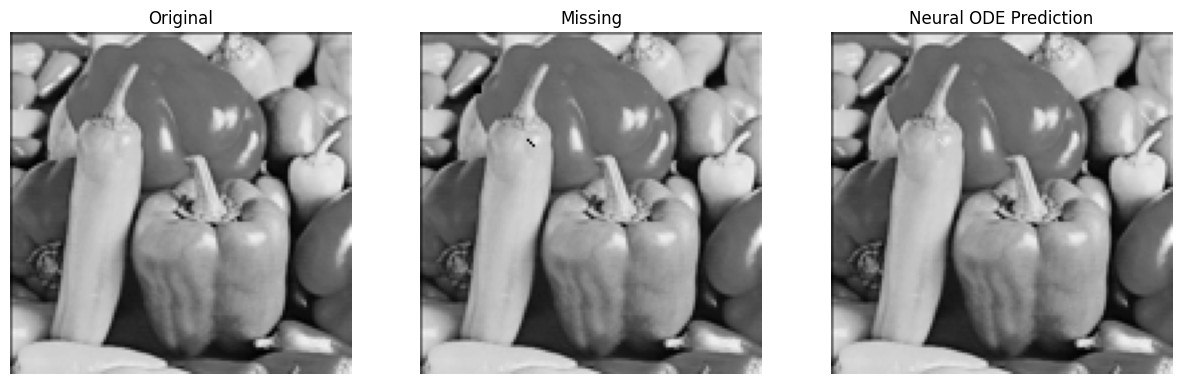

In [6]:
# ============================================
# Neural ODE 画像欠損補間（修正版）
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# 画像読み込み
# ============================================

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")

# 解像度
img = img.resize((128,128))

# numpy化
img_array = np.array(img).astype(np.float32)

# 0〜1正規化
img_array = img_array / 255.0

# ============================================
# 座標作成
# ============================================

height, width = img_array.shape

# 座標正規化（重要）
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ============================================
# 欠損作成
# ============================================

mask = np.ones(img_array.shape, dtype=bool)

# 欠損させるピクセル
missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]

# 欠損化
for i,j in missing_points:

    mask[i,j] = False

# 欠損画像
img_missing = img_array.copy()

img_missing[~mask] = np.nan

# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全画素予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ============================================
# 欠損部分だけ補間
# ============================================

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ============================================
# 欠損点精度表示
# ============================================

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()